# K Nearest Neighbor Classifier

### Predict the label of a data point by

   * Looking at the $k$ closest labeled data points

   * Taking a majority vote

<center><img src="knn_classifier.png" width="200"/></center>
<br />
<center>Example of k-NN classification.</center>

In [13]:
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.model_selection import cross_val_score

## Loading Data

In [2]:
# Load wine dataset from sklearn
wine = load_wine()

# Get the detailed description of wine dataset
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

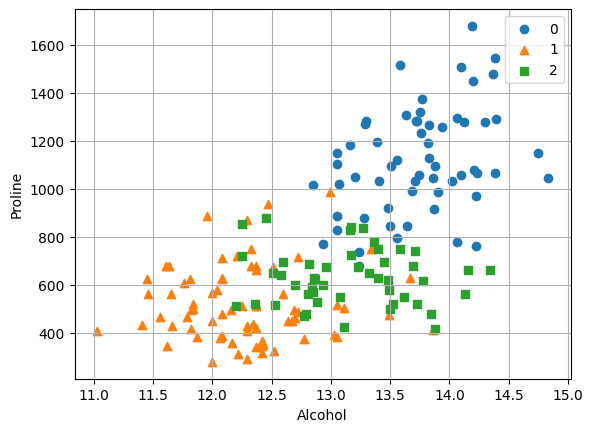

In [6]:
############################################ Task 1 ############################################
# Display the three classes in a 2D plot using only the two features 'alcohol' and 'proline'
# ----------------------------------------- start here -----------------------------------------

# Take 'Alcohol' and 'Proline' as features

# df = pd.DataFrame(wine.data, columns=wine.feature_names)

X = wine.data[:,[0, -1]]
y = wine.target



# Visualize the data
plt.scatter(X[y == 0][:,0], X[y == 0][:,1], marker='o', label='0')
plt.scatter(X[y == 1][:,0], X[y == 1][:,1], marker='^', label='1')
plt.scatter(X[y == 2][:,0], X[y == 2][:,1], marker='s', label='2')



plt.xlabel('Alcohol')
plt.ylabel('Proline')
plt.legend(loc = 'best')
plt.grid()
plt.show()

## Feature Scaling

#### Why feature scaling is important?

K-nearest neighbors uses the distance between data points to determine their similarity. Hence, features with a greater magnitude will be assigned a higher weight, this makes the model to be heavily biased toward a single feature.

#### MinMaxScaler:

$$x_{normalized} = (x – x_{min}) / (x_{max} – x_{min})$$

#### StandardScaler:

$$x_{standardized} = (x – mean(x)) / std(x)$$

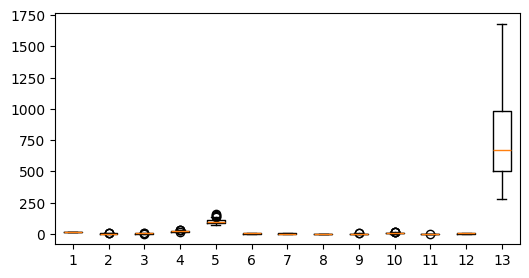

In [7]:
############################################ Task 2 ############################################
# Display the different scales of the features by plotting parallel box plots
# ----------------------------------------- start here -----------------------------------------

# Plot all features in Boxplots
fig = plt.figure(figsize =(6, 3))
plt.boxplot(wine.data)
plt.show()

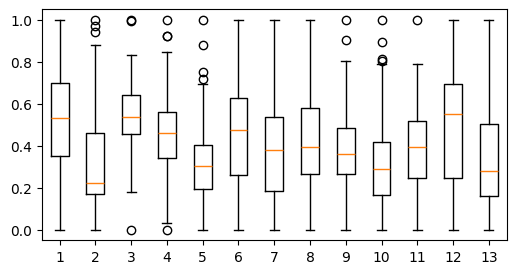

In [8]:
# Use MinMaxScaler to standardize the data
# ----------------------------------------- start here -----------------------------------------

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
wine_minmax = scaler.fit_transform(wine.data)

# Plot all scaled features in Boxplots
fig = plt.figure(figsize =(6, 3))
plt.boxplot(wine_minmax)
plt.show()

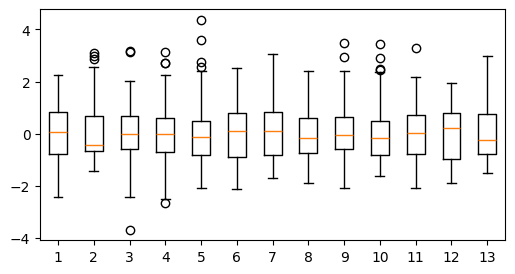

In [9]:
# Use StandardScaler to standardize the data
# ----------------------------------------- start here -----------------------------------------

# Scale the features using StandardScaler
scaler = StandardScaler()
wine_std = scaler.fit_transform(wine.data)

# Plot all scaled features in Boxplots
fig = plt.figure(figsize =(6, 3))
plt.boxplot(wine_std)
plt.show()


## Splitting the Data & Fitting Model

In [10]:
############################################ Task 3 ############################################
# Split the scaled data into training and test sets (80-20 split)
# ----------------------------------------- start here -----------------------------------------

# Scale the features using StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


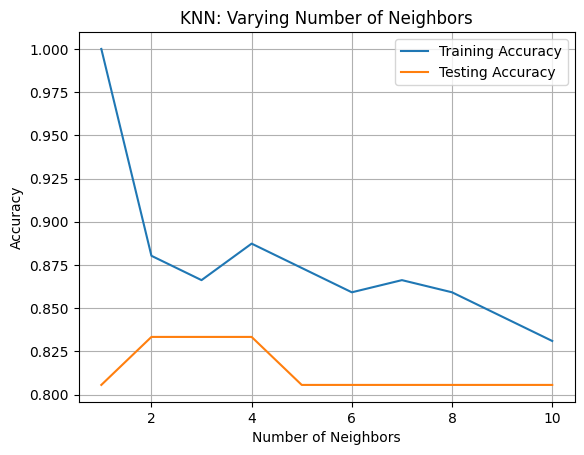

In [11]:
# Train k nearest neighbors with k ∈ {1, . . . , 10} using KNeighborsClassifier from sklearn.neighbors
# Compute the training and test error w.r.t. 0-1 loss
# ----------------------------------------- start here -----------------------------------------

# Create neighbors
neighbors = np.arange(1,11)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:
    # Set up a KNN Classifier
    knnc = KNeighborsClassifier(n_neighbors=neighbor)
    # Fit the model
    knnc.fit(X_train, y_train)
    # Compute accuracy
    train_accuracies[neighbor] = knnc.score(X_train, y_train)
    test_accuracies[neighbor] = knnc.score(X_test, y_test)
    
# Add a title
plt.title("KNN: Varying Number of Neighbors")
# Plot training accuracies
plt.plot(neighbors, list(train_accuracies.values()), label="Training Accuracy")
# Plot test accuracies
plt.plot(neighbors, list(test_accuracies.values()), label="Testing Accuracy")
plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.grid()
# Display the plot
plt.show()

(178, 2)


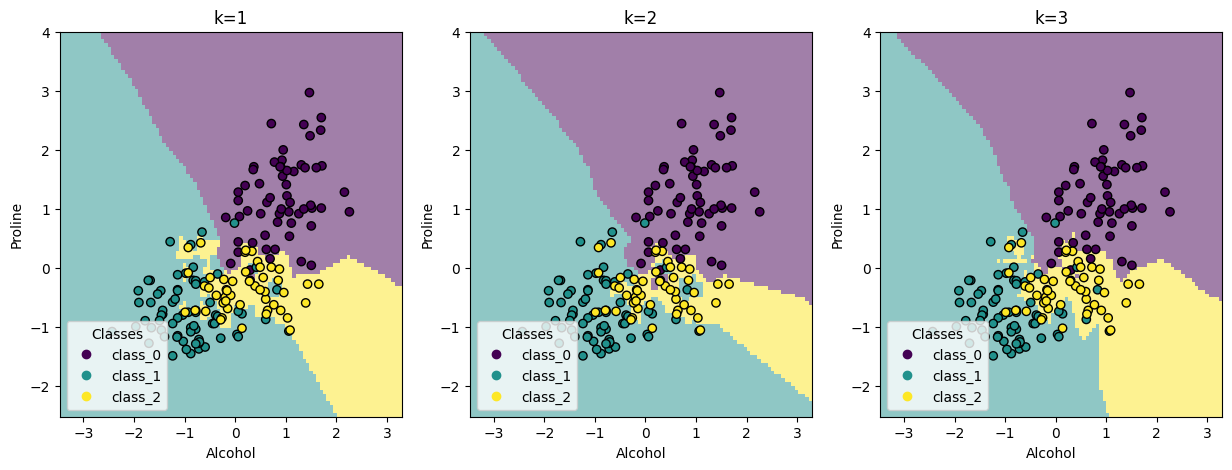

In [12]:
# Display the decision boundaries for k = 1, k = 10, and your best choice of k in the 2D plot
# ----------------------------------------- start here -----------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
print(X.shape)
neighbos = [1, 4, 10]
for i in range(3):
    # Set up a KNN Classifier
    knnc = KNeighborsClassifier(n_neighbors=neighbors[i])
    # Fit the model
    knnc.fit(X_train, y_train)
    # plot the decision boundary of the classifier
    disp = DecisionBoundaryDisplay.from_estimator(knnc, X, response_method="predict", plot_method="pcolormesh",
                                                  xlabel='Alcohol', ylabel='Proline', ax=axs[i], alpha=0.5)
    scatter = disp.ax_.scatter(X[:, 0], X[:,1], c=y, edgecolors="k")
    disp.ax_.legend(scatter.legend_elements()[0], wine.target_names, loc="lower left", title="Classes",)
    _ = disp.ax_.set_title(f"k={knnc.n_neighbors}")
    

Training accuracies: {0: 0.8873239436619719, 1: 0.8873239436619719, 2: 0.823943661971831}
Test accuracies: {0: 0.8333333333333334, 1: 0.8055555555555556, 2: 0.8333333333333334}


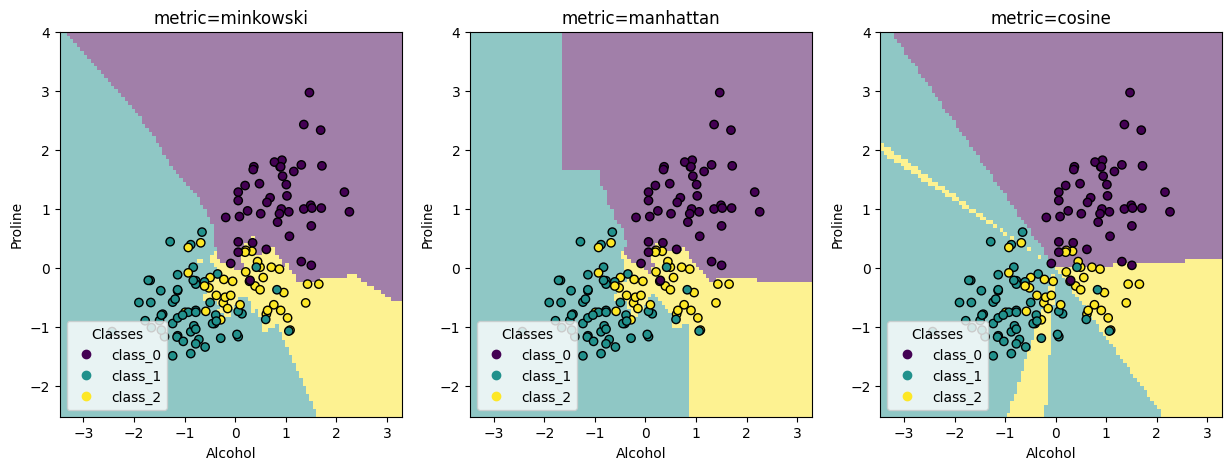

In [15]:
############################################ Task 4 ############################################
# Choose k as before (optimal choice from previous task) and vary between Minkowski, Manhatten, and cosine distance
# Again plot the decision boundarys and report the training and test accuracies
# ----------------------------------------- start here -----------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["minkowski", "manhattan", "cosine"]
train_accuracies = {}
test_accuracies = {}
for i in range(3):
    # Set up a KNN Classifier
    knnc = KNeighborsClassifier(n_neighbors=4, metric=metrics[i])
    # Fit the model
    knnc.fit(X_train, y_train)
    # plot the decision boundary of the classifier
    disp = DecisionBoundaryDisplay.from_estimator(knnc, X_train, response_method="predict", plot_method="pcolormesh",
                                                  xlabel='Alcohol', ylabel='Proline', ax=axs[i], alpha=0.5)
    scatter = disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="k")
    disp.ax_.legend(scatter.legend_elements()[0], wine.target_names, loc="lower left", title="Classes",)
    _ = disp.ax_.set_title(f"metric={metrics[i]}")
    
    # Compute the accuracies on the training set and the test set
    train_accuracies[i] = knnc.score(X_train, y_train)
    test_accuracies[i] = knnc.score(X_test, y_test)

# Print the accuracies on the training set and the test set
print("Training accuracies:", train_accuracies)
print("Test accuracies:", test_accuracies)

## Hyperparameter tuning

#### Grid search


<img src="gridsearch.png" width="500"/>

   #### k-fold cross validation


<img src="kfold_validation.png" width="800"/>

In [16]:
############################################ Task 5 ############################################
# Perform a grid search to find the best combination of k ∈ {2, 3, 4, 5, 6, 7}, 
# metric (Minkowski, Manhatten, cosine), and weights (uniform, distance)
# ----------------------------------------- start here -----------------------------------------

# Create a KNN Classifier
knn_gs = KNeighborsClassifier()

# Setup GridSearchCV
params = {
    "n_neighbors": [2, 3, 4, 5, 6, 7],
    "metric": ["minkowski", "manhattan", "cosine"],
    "weights": ["uniform", "distance"]
}

gs = GridSearchCV(estimator=knn_gs, param_grid=params, scoring='accuracy', cv=5)

# Fit GridSearchCV
gs.fit(X, y)

# Print the best combination of parameters
print("Best parameters:", gs.best_params_)
print("Best accuracy:", gs.best_score_)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'}
Best accuracy: 0.8426984126984127


In [19]:
import pandas as pd
pd.DataFrame.from_dict(gs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000771,0.000239,0.001810,0.000381,minkowski,2,uniform,"{'metric': 'minkowski', 'n_neighbors': 2, 'wei...",0.722222,0.777778,0.750000,0.771429,0.828571,0.770000,0.035145,28
1,0.000539,0.000021,0.001003,0.000074,minkowski,2,distance,"{'metric': 'minkowski', 'n_neighbors': 2, 'wei...",0.638889,0.777778,0.861111,0.714286,0.942857,0.786984,0.106858,24
2,0.000534,0.000012,0.001396,0.000031,minkowski,3,uniform,"{'metric': 'minkowski', 'n_neighbors': 3, 'wei...",0.638889,0.805556,0.805556,0.800000,0.885714,0.787143,0.080671,22
3,0.000529,0.000011,0.001043,0.000139,minkowski,3,distance,"{'metric': 'minkowski', 'n_neighbors': 3, 'wei...",0.666667,0.833333,0.861111,0.742857,0.942857,0.809365,0.095769,9
4,0.000538,0.000006,0.001379,0.000021,minkowski,4,uniform,"{'metric': 'minkowski', 'n_neighbors': 4, 'wei...",0.750000,0.805556,0.833333,0.800000,0.828571,0.803492,0.029656,16
5,0.000531,0.000020,0.000981,0.000048,minkowski,4,distance,"{'metric': 'minkowski', 'n_neighbors': 4, 'wei...",0.666667,0.861111,0.833333,0.800000,0.942857,0.820794,0.090410,3
6,0.000501,0.000003,0.001394,0.000033,minkowski,5,uniform,"{'metric': 'minkowski', 'n_neighbors': 5, 'wei...",0.722222,0.777778,0.833333,0.771429,0.885714,0.798095,0.056213,20
7,0.000534,0.000018,0.000995,0.000027,minkowski,5,distance,"{'metric': 'minkowski', 'n_neighbors': 5, 'wei...",0.666667,0.833333,0.861111,0.771429,0.942857,0.815079,0.092424,5
8,0.000519,0.000008,0.001406,0.000029,minkowski,6,uniform,"{'metric': 'minkowski', 'n_neighbors': 6, 'wei...",0.722222,0.777778,0.888889,0.828571,0.885714,0.820635,0.063998,4
9,0.000505,0.000011,0.001004,0.000054,minkowski,6,distance,"{'metric': 'minkowski', 'n_neighbors': 6, 'wei...",0.638889,0.805556,0.861111,0.771429,0.914286,0.798254,0.093364,17


In [21]:
# Estimate the generalization error (w.r.t. 0-1 loss) for the chosen best set of hyperparameters
# ----------------------------------------- start here -----------------------------------------

# Set up knn with the best combination of parameters
knn = KNeighborsClassifier(**gs.best_params_)

# Fit knn model
knn.fit(X_train, y_train)

# Predict test data with knn model
y_pred = knn.predict(X_test)

# Calculate the accuracy of predictions
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print("Accuracy:", accuracy)
print("Generalization Error", 1-accuracy)

Accuracy: 0.8333333333333334
Generalization Error 0.16666666666666663


## Add more features

In [23]:
best_features = [0, 12]
num_features = wine.data.shape[1]
all_features = list(range(num_features))

In [24]:
feature_order = best_features + [i for i in all_features if i not in best_features]
feature_order

[0, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [25]:
############################################ Task 6 ############################################
# ----------------------------------------- start here -----------------------------------------

# Build feature addition list
# feature_order = 

scores = []
scores_scaler = []

for i in range(2, len(feature_order) + 1):
    
    # Increase features gradually
    selected = feature_order[:i]
    X_cv = wine.data[:, selected]
    y_cv = wine.target
    
    # Scale the features using StandardScaler
    scaler = StandardScaler()
    X_cv_scaler = scaler.fit_transform(X_cv)
    
    # Create a KNN classifier with the best combination of parameters
    knn_cv = KNeighborsClassifier(**gs.best_params_)
    
    # Calculate cross validaton errors for raw data
    score_cv = cross_val_score(knn_cv, X_cv, y_cv, cv=5)
    
    # Calculate cross validaton errors for standardized data
    score_cv_scaler = cross_val_score(knn_cv, X_cv_scaler, y_cv, cv=5)
    print(score_cv_scaler)
    
    # Add cross validaton errors for raw data to a list
    scores.append(score_cv.mean())
    
    # Add cross validaton errors for standardized data to a list
    scores_scaler.append(score_cv_scaler) 

[0.75       0.86111111 0.91666667 0.8        0.88571429]
[0.75       0.80555556 0.86111111 0.85714286 0.74285714]
[0.77777778 0.83333333 0.88888889 0.82857143 0.82857143]
[0.80555556 0.86111111 0.94444444 0.88571429 0.82857143]
[0.86111111 0.88888889 0.91666667 0.85714286 0.82857143]
[0.91666667 0.86111111 0.86111111 0.97142857 0.88571429]
[0.86111111 0.94444444 0.88888889 1.         0.97142857]
[0.83333333 0.94444444 0.94444444 0.97142857 0.97142857]
[0.83333333 0.94444444 0.91666667 0.97142857 1.        ]
[0.86111111 0.97222222 1.         1.         0.97142857]
[0.86111111 0.97222222 1.         0.97142857 0.97142857]
[0.91666667 0.94444444 1.         0.97142857 0.94285714]


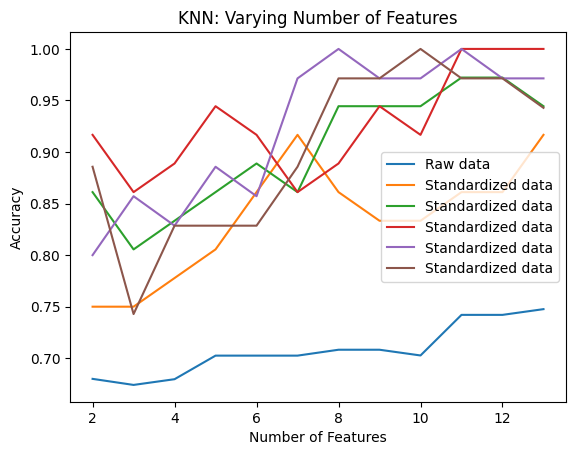

In [27]:
# Compare cross validaton errors between raw data and standardized data
plt.title("KNN: Varying Number of Features")
plt.plot(np.arange(2, 14), scores, label='Raw data')
plt.plot(np.arange(2, 14), scores_scaler, label='Standardized data')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()